In [1]:
from Loop import Train_model
from Model import Unet
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast
from Dataset import Boot_Segmentation_Dataset
from torchvision.transforms import ToPILImage
import yaml
from PIL import Image
from Batching import img2batch,batch2img,img4batch,batch4img
from torch.optim import AdamW
from torch.nn import BCELoss
import torch
from torch import nn
import cv2
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

In [2]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [3]:
dataset=Boot_Segmentation_Dataset(option['Segmentation']['img_path'],option['Segmentation']['label_path'],)
dataloader=DataLoader(dataset=dataset,batch_size=2,drop_last=False,shuffle=True)
assert dataset.all_items[0].split('/')[-1][:-4]==dataset.all_labels[0].split('/')[-1][:-4]

In [4]:
for batch in dataloader:
  bt=batch
  break

In [5]:
model=Unet(3,64).to(device)
try:
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/SegmData/unet_model_{device}.pth',weights_only=True)
    model.load_state_dict(weights_dict)
    print('Найдены веса')
except:
    print('Весов нет, инициализируем новые')

Найдены веса


In [6]:
sig=nn.Sigmoid()

In [7]:
def cut_boot_from_photo(img,mask):
    sig=nn.Sigmoid()
    real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2)
    new_img=real_mask.float()*img
    non_mask = (sig(mask)<(sig(mask).max()+sig(mask).min())/2).float()
    new_img+=non_mask
    return new_img,real_mask,non_mask

In [8]:
new_batch=adjust_sharpness(adjust_contrast(bt['img'],2),2)
new_img,real_mask,non_mask=cut_boot_from_photo(bt['img'][0],model(new_batch)[0])

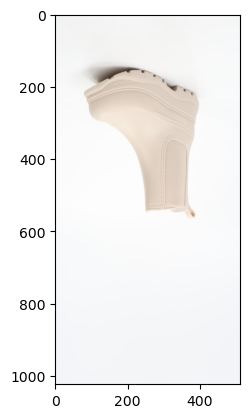

In [9]:
plt.imshow(bt['img'][0].permute(1,2,0).detach())

In [10]:
newnew_img=non_mask*new_batch[0]


In [11]:
newnew_img[newnew_img==0]=1

In [12]:
newnew_img.shape

torch.Size([3, 1024, 512])

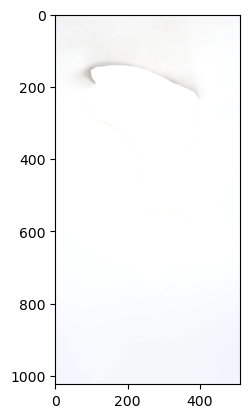

In [13]:
plt.imshow(newnew_img.permute(1,2,0).detach())

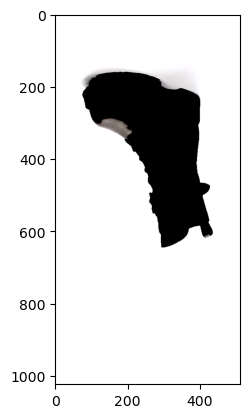

In [14]:
plt.imshow((non_mask*new_batch[0]).permute(1,2,0).detach())

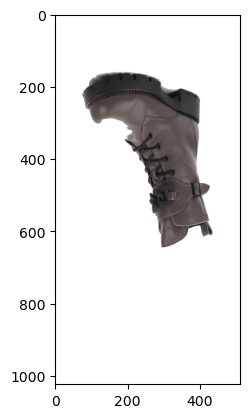

In [27]:
plt.imshow(new_img.permute(1,2,0).detach())

In [ ]:
Плавная маска:

In [45]:
mask = (real_mask.permute(1,2,0).numpy() * 255).astype(np.uint8)  # → [0, 255]

# Размытие Гаусса: ядро 15x15, сильность размытия sigma=5
blurred = cv2.GaussianBlur(mask, ksize=(15, 15), sigmaX=5)

# Возвращаем в [0, 1] если нужно
soft_mask = blurred.astype(np.float32) / 255.0

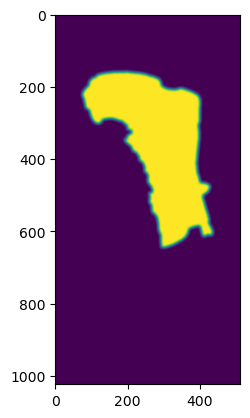

In [46]:
plt.imshow(soft_mask)

In [22]:
newnew_img>0.8

tensor([[[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]],

        [[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]],

        [[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]]]

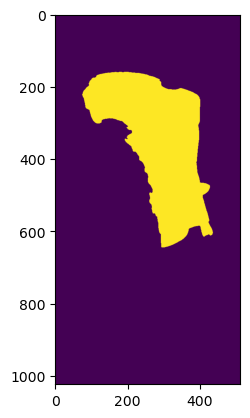

In [26]:
plt.imshow(real_mask.float().permute(1,2,0).detach())

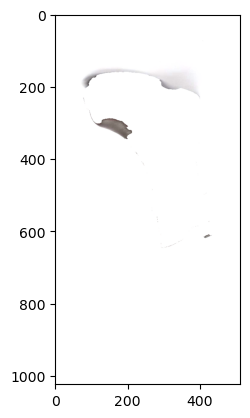

In [16]:
plt.imshow((newnew_img).float().permute(1,2,0).detach())

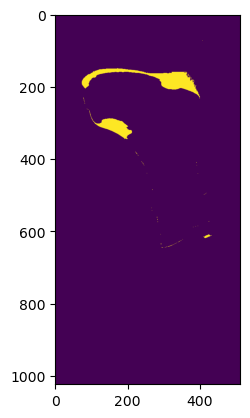

In [24]:
plt.imshow(newnew_img.mean(axis=0)<0.95)

In [111]:
newnew_img.mean(axis=0).shape

torch.Size([1024, 512])

In [112]:
(newnew_img.sum(axis=0)/3).shape

torch.Size([1024, 512])

In [113]:
newnew_img.mean(axis=0).mean()

tensor(0.9867)

In [136]:
newnew_img.mean(axis=0)>0.95

tensor([[ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        ...,
        [ True,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False]])

In [ ]:
plt.imshow(((newnew_img.mean(axis=0)>0.9999999)).float().detach())